In [161]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
import os
os.chdir('/content/drive/My Drive/projet-image-detection/code')

In [163]:
os.listdir('.')  # affiche les fichiers du dossier

['detection_couleur_forme.ipynb']

In [164]:
pip install opencv-python numpy imutils

In [165]:
pip install webcolors scipy

opencv-python → bibliothèque de traitement d'images

numpy → calculs mathématiques sur des tableaux

imutils → fonctions utilitaires pour OpenCV

webcolors → conversion de couleurs en noms

scipy → algorithmes scientifiques (KDTree)

In [166]:
!pip install webcolors==1.11.1

In [167]:
import cv2
import numpy as np
import imutils
import webcolors

from scipy.spatial import KDTree
import webcolors
from webcolors import CSS3_HEX_TO_NAMES, hex_to_rgb
from google.colab.patches import cv2_imshow

Quand OpenCV lit une image, il ne donne pas le nom de la couleur mais seulement les valeurs RGB des pixels. La base CSS contient les couleurs en HEX, donc on les convertit en RGB pour pouvoir les comparer avec les couleurs de l’image. Comme les couleurs détectées ne correspondent pas toujours exactement aux valeurs de la base, on utilise KDTree pour calculer la distance et trouver la couleur la plus proche.

In [168]:
def convert_rgb_to_names(rgb_tuple):

    css3_db = CSS3_HEX_TO_NAMES
    names = []
    rgb_values = []

    for hex_color, color_name in css3_db.items():
        names.append(color_name)
        rgb_values.append(hex_to_rgb(hex_color))

    kdt_db = KDTree(rgb_values)
    distance, index = kdt_db.query(rgb_tuple)

    return names[index]

1️⃣ détecter le contour

2️⃣ simplifier le contour avec :approxPolyDP

3️⃣ compter le nombre de sommets

4️⃣ déterminer la forme

In [169]:
class ShapeDetector:

    def detect(self, c):
      #c:le contour

        shape = "unidentified"

        peri = cv2.arcLength(c, True) #Calcul du périmètre du contour(True:conteur ferme)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)#Approximation du contour

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)
            ar = w / float(h)

            if 0.95 <= ar <= 1.05:
                shape = "square"
            else:
                shape = "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        elif len(approx) == 10:
            shape = "star"

        else:
            shape = "circle"

        return shape

In [170]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [171]:
image = cv2.imread("/content/drive/MyDrive/projet-image-detection/Image/Image.png")

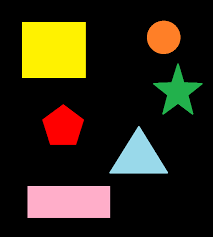

In [172]:
cv2_imshow(image)

Image originale

Resize (plus rapide)

Grayscale (simplifier)

Gaussian Blur (enlever bruit)
      
Threshold (noir/blanc)

In [173]:
#la phase de prétraitement de l’image
resized = imutils.resize(image, width=600)
ratio = image.shape[0] / float(resized.shape[0]) #calcule le rapport de taille entre l’image originale et l’image redimensionnée.

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)#Convertir l’image en niveaux de gris pour detecter la forme
blurred = cv2.GaussianBlur(gray, (5,5), 0)#Appliquer un flou pour réduire le bruit dans l’image

thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)[1]#Cette fonction transforme l’image en image binaire.

In [174]:
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)
#thresh est l’image binaire (noir/blanc) obtenue après le threshold
#RETR_EXTERNAL prendre seulement les contours externes
#cv2.CHAIN_APPROX_SIMPLE Cela sert à simplifier le stockage des contours.

cnts = imutils.grab_contours(cnts)
#la variable cnts peut contenir plusieurs éléments grab_contours() sert à extraire uniquement la liste des contours.

sd = ShapeDetector()
#Ici on crée un objet de la classe ShapeDetector

In [175]:
for c in cnts:

    M = cv2.moments(c)

    if M["m00"] == 0:
        continue

    cX = int((M["m10"] / M["m00"]) * ratio)
    cY = int((M["m01"] / M["m00"]) * ratio)
    #coordonnées du centre du contour dans l’image originale.

    shape = sd.detect(c)

    c = c.astype("float")
    c *= ratio
    c = c.astype("int")

    cv2.drawContours(image, [c], -1, (0,255,0), 2)
    #Dessiner le contour sur l’image

    mask = np.zeros(image.shape[:2], np.uint8)
    cv2.drawContours(mask, [c], -1, 255, -1)

    imgRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mean = cv2.mean(imgRGB, mask=mask)[:3]
    #Calcul de la couleur moyenne

    named_color = convert_rgb_to_names(mean)
    #Convertir la couleur en nom

    label = shape + " " + named_color

    cv2.putText(image, label, (cX - 30, cY),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4, (255,255,255), 1)

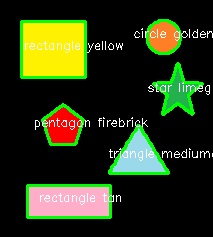

In [176]:
cv2_imshow(image)